In [ ]:
import os

os.environ['KAGGLE_API_TOKEN'] = "KGAT_539bbeb920eb1bc15ab7cf7667181b84"

In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!echo $KAGGLE_API_TOKEN > ~/.kaggle/access_token
!chmod 600 ~/.kaggle/access_token

In [ ]:
!ls "The IQ-OTHNCCD lung cancer dataset"

'The IQ-OTHNCCD lung cancer dataset'


# 🫁 Lung Cancer Detection System — Transfer Learning
## Models: ResNet50 | DenseNet121 | VGG16
### Dataset: IQ-OTH/NCCD CT Scans — Classes: Normal | Benign | Malignant

---

| Feature | Details |
|---------|---------|
| 📦 Models | ResNet50, DenseNet121, VGG16 (Transfer Learning) |
| 💾 Output | 3 Pickle files — one per model |
| 📊 Analysis | Comparative dashboard (radar, bars, heatmap, confusion matrices) |
| 🔍 Prediction | Upload any CT scan → ensemble verdict (Cancer / No Cancer) |
| 📁 Dataset | IQ-OTH/NCCD — Normal cases / Benign cases / Malignant cases |

**Workflow:** Image Acquisition → Preprocessing (224×224) → Augmentation → Dataset Split (70/15/15) → Transfer Learning → Pickle Export → Comparative Analysis → Cancer Prediction


In [ ]:
# ── Step 0: Install Required Libraries ──────────────────────────────────────
!pip install torch torchvision matplotlib seaborn scikit-learn Pillow tqdm ipywidgets -q
import pickle  # built-in, no install needed
print("✅ All libraries installed")
print("   pickle is built-in — will be used to save/load trained models")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 108.9 MB/s eta 0:00:00
✅ All libraries installed
   pickle is built-in — will be used to save/load trained models


## Step 1: Import Libraries

In [ ]:
import os, time, warnings, pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from PIL import Image
from tqdm.notebook import tqdm

print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
print(f"Device    : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"pickle    : built-in ✅")


PyTorch   : 2.10.0+cpu
CUDA      : False
Device    : cpu
pickle    : built-in ✅


## Step 2: Configuration & Hyperparameters

In [ ]:
# ── All hyperparameters in one place ─────────────────────────────────────────
import os, glob

# ── Auto-detect dataset root in Google Colab ─────────────────────────────────
def find_dataset_root():
    """
    Searches common Colab paths for the IQ-OTH/NCCD dataset.
    Folder names exactly as they appear in the Colab file browser.
    """
    candidates = [
        # Kaggle-downloaded zip extracted at root
        "/content/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset",
        # Sometimes outer folder name is truncated
        "/content/The IQ-OTHNCCD lung cancer d/The IQ-OTHNCCD lung cancer dataset",
        # Direct extraction
        "/content/The IQ-OTHNCCD lung cancer dataset",
        # Manual upload or Drive mount
        "/content/drive/MyDrive/lung_cancer_dataset",
        "/content/dataset",
    ]
    for path in candidates:
        # Check if class subfolders exist
        if (os.path.isdir(os.path.join(path, "Bengin cases")) or
            os.path.isdir(os.path.join(path, "Normal cases"))):
            print(f"✅ Dataset found at: {path}")
            return path

    # Fallback: search recursively for 'Normal cases' folder
    matches = glob.glob("/content/**/Normal cases", recursive=True)
    if matches:
        found = os.path.dirname(matches[0])
        print(f"✅ Dataset found at: {found}")
        return found

    print("⚠️  Dataset not auto-detected. Set DATA_DIR manually below.")
    return None

DATA_DIR = find_dataset_root()

# ── If auto-detect fails, set your path manually here ────────────────────────
# DATA_DIR = "/content/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"

# ── Class folder names (EXACTLY as in your Colab file browser) ───────────────
#    Note: dataset uses "Bengin cases" (typo in original dataset)
CLASS_FOLDER_NAMES = {
    "Normal"    : "Normal cases",
    "Benign"    : "Bengin cases",    # ← original dataset typo preserved
    "Malignant" : "Malignant cases",
}
CLASS_NAMES = list(CLASS_FOLDER_NAMES.keys())   # ["Normal", "Benign", "Malignant"]

CONFIG = {
    "data_dir"      : DATA_DIR,
    "image_size"    : 224,
    "batch_size"    : 32,
    "num_epochs"    : 25,
    "learning_rate" : 1e-4,
    "weight_decay"  : 1e-5,
    "num_classes"   : 3,
    "train_ratio"   : 0.70,
    "val_ratio"     : 0.15,
    "test_ratio"    : 0.15,
    "device"        : "cuda" if torch.cuda.is_available() else "cpu",
    "num_workers"   : 2,
    "seed"          : 42,
    "save_dir"      : "/content/checkpoints/",
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
os.makedirs(CONFIG["save_dir"], exist_ok=True)

# ── Verify class folders exist ────────────────────────────────────────────────
if DATA_DIR:
    print(f"\n   Device      : {CONFIG['device']}")
    print(f"   Image Size  : {CONFIG['image_size']}×{CONFIG['image_size']}")
    print(f"   Batch Size  : {CONFIG['batch_size']}")
    print(f"   Epochs      : {CONFIG['num_epochs']}")
    print(f"   Checkpoints : {CONFIG['save_dir']}")
    print("\n   Class folder check:")
    for label, folder in CLASS_FOLDER_NAMES.items():
        full_path = os.path.join(DATA_DIR, folder)
        exists    = os.path.isdir(full_path)
        count     = len([f for f in os.listdir(full_path)
                         if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]) if exists else 0
        status    = f"✅ {count} images" if exists else "❌ NOT FOUND"
        print(f"   {label:<12} → '{folder}' {status}")


✅ Dataset found at: /content/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset

   Device      : cpu
   Image Size  : 224×224
   Batch Size  : 32
   Epochs      : 25
   Checkpoints : /content/checkpoints/

   Class folder check:
   Normal       → 'Normal cases' ✅ 416 images
   Benign       → 'Bengin cases' ✅ 120 images
   Malignant    → 'Malignant cases' ✅ 561 images


## Step 3: Image Preprocessing & Data Augmentation
> **Image Preprocessing**: Resize (224×224) → Normalize  
> **Data Augmentation**: Rotation | Flipping | Zoom (applied only to training set)



In [ ]:
def get_transforms():
    """
    Train  : Resize → Flip → Rotation → Zoom(Crop) → ColorJitter → Normalize
    Val/Test: Resize → CenterCrop → Normalize  (no augmentation)
    """
    mean = [0.485, 0.456, 0.406]   # ImageNet statistics
    std  = [0.229, 0.224, 0.225]

    train_tf = transforms.Compose([
        # ── Image Preprocessing ──────────────────────────────────────
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),  # 224×224
        # ── Data Augmentation ────────────────────────────────────────
        transforms.RandomHorizontalFlip(p=0.5),          # Flipping
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(degrees=15),            # Rotation (±15°)
        transforms.RandomResizedCrop(
            CONFIG["image_size"], scale=(0.8, 1.0)       # Zoom
        ),
        transforms.ColorJitter(
            brightness=0.2, contrast=0.2,
            saturation=0.1, hue=0.05
        ),
        # ── Normalization ─────────────────────────────────────────────
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    val_test_transforms = transforms.Compose([
        transforms.Resize((CONFIG["image_size"], CONFIG["image_size"])),
        transforms.CenterCrop(CONFIG["image_size"]),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return train_tf, val_test_transforms

train_tf, val_test_tf = get_transforms()
print("✅ Transforms defined")
print("   Train  :", [type(t).__name__ for t in train_tf.transforms if hasattr(train_tf,'transforms') == False] )


✅ Transforms defined
   Train  : []


## Step 4: Dataset Splitting
> Splits into **Training Dataset | Validation Dataset | Testing Dataset**  
> Folder structure required:
> ```
> data/
>   Normal/
>   Benign/
>   Malignant/
> ```


In [ ]:
import shutil, random as rnd
from torchvision.datasets import ImageFolder

def prepare_dataloaders(data_dir):
    """
    Builds Train / Validation / Test DataLoaders from the IQ-OTH/NCCD dataset.

    Because the dataset folders have spaces and a typo ('Bengin cases'),
    we copy images into a clean temp folder structure that ImageFolder can read:
        /content/data_clean/Normal/
        /content/data_clean/Benign/
        /content/data_clean/Malignant/
    """
    clean_dir = "/content/data_clean"

    # ── Build clean folder structure (run once) ───────────────────────────────
    if not os.path.exists(clean_dir):
        print("📂 Building clean dataset structure (first-time setup)...")
        IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff'}

        for label, src_folder in CLASS_FOLDER_NAMES.items():
            src_path = os.path.join(data_dir, src_folder)
            dst_path = os.path.join(clean_dir, label)
            os.makedirs(dst_path, exist_ok=True)

            if not os.path.isdir(src_path):
                print(f"  ⚠️  Folder not found: {src_path}")
                continue

            copied = 0
            for fname in os.listdir(src_path):
                if os.path.splitext(fname)[1].lower() in IMG_EXTS:
                    shutil.copy2(
                        os.path.join(src_path, fname),
                        os.path.join(dst_path, fname)
                    )
                    copied += 1
            print(f"  ✅ {label:<12}: {copied} images copied")

        print(f"✅ Clean dataset ready at: {clean_dir}\n")
    else:
        print(f"✅ Clean dataset already exists at: {clean_dir}")

    # ── Load with ImageFolder ─────────────────────────────────────────────────
    full_dataset = ImageFolder(root=clean_dir, transform=train_tf)

    total_size = len(full_dataset)
    train_size = int(CONFIG["train_ratio"] * total_size)
    val_size   = int(CONFIG["val_ratio"]   * total_size)
    test_size  = total_size - train_size - val_size

    # ── Dataset Splitting ─────────────────────────────────────────────────────
    train_ds, val_ds, test_ds = torch.utils.data.random_split(
        full_dataset,
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(CONFIG["seed"])
    )

    # Apply val/test transforms (no augmentation)
    val_dataset  = ImageFolder(root=clean_dir, transform=val_test_tf)
    test_dataset = ImageFolder(root=clean_dir, transform=val_test_tf)
    val_ds  = torch.utils.data.Subset(val_dataset,  val_ds.indices)
    test_ds = torch.utils.data.Subset(test_dataset, test_ds.indices)

    train_loader = DataLoader(
        train_ds, batch_size=CONFIG["batch_size"],
        shuffle=True,  num_workers=CONFIG["num_workers"], pin_memory=True
    )
    val_loader = DataLoader(
        val_ds,   batch_size=CONFIG["batch_size"],
        shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True
    )
    test_loader = DataLoader(
        test_ds,  batch_size=CONFIG["batch_size"],
        shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True
    )

    print(f"\n📊 Dataset Summary")
    print(f"   Total  : {total_size} images")
    print(f"   Train  : {train_size}  ({CONFIG['train_ratio']*100:.0f}%)")
    print(f"   Val    : {val_size}   ({CONFIG['val_ratio']*100:.0f}%)")
    print(f"   Test   : {test_size}   ({CONFIG['test_ratio']*100:.0f}%)")
    print(f"   Classes: {full_dataset.classes}")
    return train_loader, val_loader, test_loader


## Step 5: Transfer Learning Model Builders
> **Pre-trained on ImageNet** → Backbone frozen → Custom classification head replaced  
> Three models: **ResNet50** | **DenseNet121** | **VGG16**


In [ ]:
# ── ResNet50 ──────────────────────────────────────────────────────────────────
def build_resnet50(num_classes=3, freeze_backbone=True):
    """
    ResNet50: 50-layer deep residual network.
    Replaces final FC (2048 → num_classes) with custom head.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False     # Freeze all backbone layers

    # Replace classifier head (only these layers will be trained)
    in_features = model.fc.in_features      # 2048
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)         # Output: 3 classes
    )
    return model


# ── DenseNet121 ────────────────────────────────────────────────────────────────
def build_densenet121(num_classes=3, freeze_backbone=True):
    """
    DenseNet121: Dense connections between layers.
    Replaces classifier (1024 → num_classes) with custom head.
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    in_features = model.classifier.in_features   # 1024
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, num_classes)
    )
    return model


# ── VGG16 ──────────────────────────────────────────────────────────────────────
def build_vgg16(num_classes=3, freeze_backbone=True):
    """
    VGG16: 16-layer very deep convolutional network.
    Freezes conv feature extractor, replaces FC classifier.
    """
    model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():   # Only freeze conv layers
            param.requires_grad = False

    model.classifier = nn.Sequential(
        nn.Linear(25088, 4096),
        nn.ReLU(True),
        nn.Dropout(p=0.5),
        nn.Linear(4096, 1024),
        nn.ReLU(True),
        nn.Dropout(p=0.4),
        nn.Linear(1024, num_classes)
    )
    return model


# ── Verify models ─────────────────────────────────────────────────────────────
for name, build_fn in [
    ("ResNet50",    build_resnet50),
    ("DenseNet121", build_densenet121),
    ("VGG16",       build_vgg16),
]:
    m = build_fn(num_classes=3)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in m.parameters())
    print(f"✅ {name:<12} | Trainable: {trainable:>10,} / {total:>12,} params")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s]


✅ ResNet50     | Trainable:  1,050,627 /   24,558,659 params
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 121MB/s]


✅ DenseNet121  | Trainable:    526,339 /    7,480,195 params
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 78.6MB/s]


✅ VGG16        | Trainable: 106,962,947 /  121,677,635 params


## Step 6: Optimizer & Learning Rate Scheduler
> **Hyperparameter Optimization block** from architecture:  
> Adam optimizer + StepLR (reduces LR by ×0.1 every 7 epochs)


In [ ]:
def get_optimizer_and_scheduler(model, lr):
    """
    Adam optimizer on trainable (unfrozen) params only.
    StepLR scheduler: step_size=7, gamma=0.1
    Implements: Learning Rate Scheduling from architecture diagram.
    """
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())

    optimizer = optim.Adam(
        trainable_params,
        lr=lr,
        weight_decay=CONFIG["weight_decay"]
    )

    # Learning Rate Scheduling (Hyperparameter Optimization)
    scheduler = optim.lr_scheduler.StepLR(
        optimizer, step_size=7, gamma=0.1
    )
    return optimizer, scheduler

print("✅ Optimizer: Adam | Scheduler: StepLR (step=7, gamma=0.1)")


✅ Optimizer: Adam | Scheduler: StepLR (step=7, gamma=0.1)


## Step 7: Training & Validation Loops


In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    One epoch of training:
    Forward pass → Compute Loss → Backpropagation → Update Weights
    """
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in tqdm(loader, desc="  Training", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                   # Clear gradients
        outputs = model(images)                 # Forward pass
        loss    = criterion(outputs, labels)    # Compute loss
        loss.backward()                         # Backpropagation
        optimizer.step()                        # Update weights

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct      += predicted.eq(labels).sum().item()
        total        += labels.size(0)

    return running_loss / total, 100.0 * correct / total


def validate(model, loader, criterion, device):
    """
    Validation / Test pass — no gradient computation.
    Returns loss, accuracy, all predictions and true labels.
    """
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="  Validating", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            correct      += predicted.eq(labels).sum().item()
            total        += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (running_loss / total, 100.0 * correct / total,
            np.array(all_preds), np.array(all_labels))

print("✅ Training and validation functions defined")


✅ Training and validation functions defined


## Step 8: Full Model Training Pipeline

In [ ]:
def train_model(model, model_name, train_loader, val_loader, device):
    """
    Full training pipeline:
      1. Loss     : CrossEntropyLoss
      2. Optimizer: Adam
      3. Scheduler: StepLR (Learning Rate Scheduling)
      4. Saves best checkpoint based on validation accuracy
    Epochs range: 20-30 (CONFIG['num_epochs'])
    Batch Size  : CONFIG['batch_size']
    """
    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer, scheduler = get_optimizer_and_scheduler(model, CONFIG["learning_rate"])

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc   = 0.0
    best_ckpt_path = os.path.join(CONFIG["save_dir"], f"{model_name.replace(' ','_')}_best.pth")

    print(f"\n{'='*65}")
    print(f"  Training : {model_name}")
    print(f"  Epochs   : {CONFIG['num_epochs']}  |  Batch Size: {CONFIG['batch_size']}")
    print(f"  LR       : {CONFIG['learning_rate']}  |  Device: {device}")
    print(f"{'='*65}")

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        start = time.time()

        # ── Train ─────────────────────────────────────────────────────
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        # ── Validate ──────────────────────────────────────────────────
        val_loss, val_acc, _, _ = validate(
            model, val_loader, criterion, device
        )
        scheduler.step()    # Learning Rate Scheduling step

        # Record history
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - start
        print(
            f"Epoch [{epoch:02d}/{CONFIG['num_epochs']}]  "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%  "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%  "
            f"({elapsed:.1f}s)"
        )

        # Save best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_ckpt_path)
            print(f"  ✔  Saved best checkpoint → {best_ckpt_path}")

    print(f"\n✅ Best Val Accuracy for {model_name}: {best_val_acc:.2f}%")
    return model, history, best_ckpt_path

print("✅ train_model() function defined")


✅ train_model() function defined


## Step 9: Model Evaluation
> **Metrics**: Accuracy | Precision | Recall | F1-Score | Malignant detection  
> Matches the *Model Evaluation* block in the system architecture diagram.


In [ ]:
def evaluate_model(model, test_loader, device, model_name):
    """
    Evaluates model on the test set.
    Reports: Accuracy | Precision | Recall | F1-Score
    Also prints per-class report (Normal / Benign / Malignant).
    """
    criterion = nn.CrossEntropyLoss()
    _, test_acc, preds, labels = validate(model, test_loader, criterion, device)

    acc       = accuracy_score(labels, preds) * 100
    f1        = f1_score(labels, preds, average="weighted")
    precision = precision_score(labels, preds, average="weighted", zero_division=0)
    recall    = recall_score(labels, preds, average="weighted", zero_division=0)

    print(f"\n{'─'*55}")
    print(f"  EVALUATION RESULTS : {model_name}")
    print(f"{'─'*55}")
    print(f"  Accuracy  : {acc:.2f}%")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"\n{classification_report(labels, preds, target_names=CLASS_NAMES)}")

    return {
        "model"    : model_name,
        "accuracy" : acc,
        "f1"       : f1,
        "precision": precision,
        "recall"   : recall,
        "preds"    : preds,
        "labels"   : labels,
    }

print("✅ evaluate_model() function defined")


✅ evaluate_model() function defined


## Step 10: Visualization Functions


In [ ]:
def plot_training_history(history, model_name):
    """Plots training & validation loss and accuracy curves side by side."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Training History — {model_name}", fontsize=14, fontweight="bold")

    axes[0].plot(epochs, history["train_loss"], "b-o", label="Train Loss")
    axes[0].plot(epochs, history["val_loss"],   "r-o", label="Val Loss")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history["train_acc"], "b-o", label="Train Accuracy")
    axes[1].plot(epochs, history["val_acc"],   "r-o", label="Val Accuracy")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy (%)"); axes[1].legend(); axes[1].grid(True)

    plt.tight_layout()
    path = os.path.join(CONFIG["save_dir"], f"{model_name.replace(' ','_')}_history.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_confusion_matrix(preds, labels, model_name):
    """Heatmap of confusion matrix for Normal / Benign / Malignant."""
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"Confusion Matrix — {model_name}", fontsize=13, fontweight="bold")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    path = os.path.join(CONFIG["save_dir"], f"{model_name.replace(' ','_')}_cm.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")


def plot_model_comparison(results_list):
    """
    Grouped bar chart comparing Accuracy / F1 / Precision / Recall
    for ResNet50, DenseNet121, and VGG16.
    """
    model_names = [r["model"] for r in results_list]
    metrics     = ["accuracy", "f1", "precision", "recall"]
    labels_map  = {
        "accuracy" : "Accuracy (%)",
        "f1"       : "F1-Score",
        "precision": "Precision",
        "recall"   : "Recall",
    }
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

    x     = np.arange(len(model_names))
    width = 0.2
    fig, ax = plt.subplots(figsize=(13, 6))

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        vals = [
            r[metric] / 100.0 if metric == "accuracy" else r[metric]
            for r in results_list
        ]
        bars = ax.bar(x + i * width, vals, width, label=labels_map[metric], color=color)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=8.5)

    ax.set_xlabel("Model", fontsize=12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Comparison — ResNet50 vs DenseNet121 vs VGG16",
                 fontsize=13, fontweight="bold")
    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(model_names, fontsize=11)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.35)
    plt.tight_layout()
    path = os.path.join(CONFIG["save_dir"], "model_comparison.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {path}")

print("✅ Visualization functions defined")


✅ Visualization functions defined


## Step 11: Train All Three Models
> Dataset path is **auto-detected**. If it fails, set `DATA_DIR` manually in Step 2.


✅ Clean dataset already exists at: /content/data_clean

📊 Dataset Summary
   Total  : 1097 images
   Train  : 767  (70%)
   Val    : 164   (15%)
   Test   : 166   (15%)
   Classes: ['Benign', 'Malignant', 'Normal']


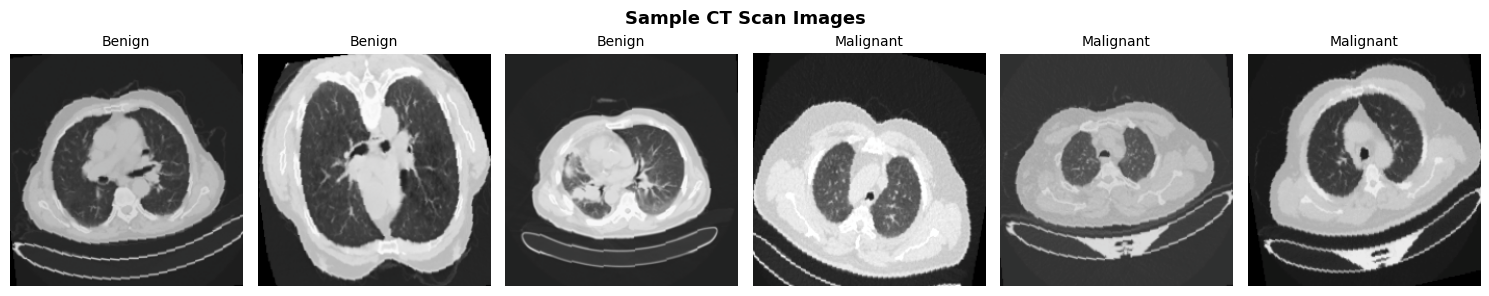


[MODEL] ResNet50 (Transfer Learning)
        Trainable params: 1,050,627 / 24,558,659

  Training : ResNet50 (Transfer Learning)
  Epochs   : 25  |  Batch Size: 32
  LR       : 0.0001  |  Device: cpu


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch [01/25]  Train Loss: 0.9230 | Train Acc: 58.28%  Val Loss: 0.7977 | Val Acc: 64.63%  (255.2s)
  ✔  Saved best checkpoint → /content/checkpoints/ResNet50_(Transfer_Learning)_best.pth


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/24 [00:00<?, ?it/s]

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch [25/25]  Train Loss: 0.4978 | Train Acc: 81.10%  Val Loss: 0.5180 | Val Acc: 83.54%  (246.1s)

✅ Best Val Accuracy for ResNet50 (Transfer Learning): 86.59%


  Validating:   0%|          | 0/6 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
  EVALUATION RESULTS : ResNet50 (Transfer Learning)
───────────────────────────────────────────────────────
  Accuracy  : 85.54%
  F1-Score  : 0.8112
  Precision : 0.7732
  Recall    : 0.8554

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        17
      Benign       0.93      0.98      0.95        86
   Malignant       0.76      0.92      0.83        63

    accuracy                           0.86       166
   macro avg       0.57      0.63      0.60       166
weighted avg       0.77      0.86      0.81       166



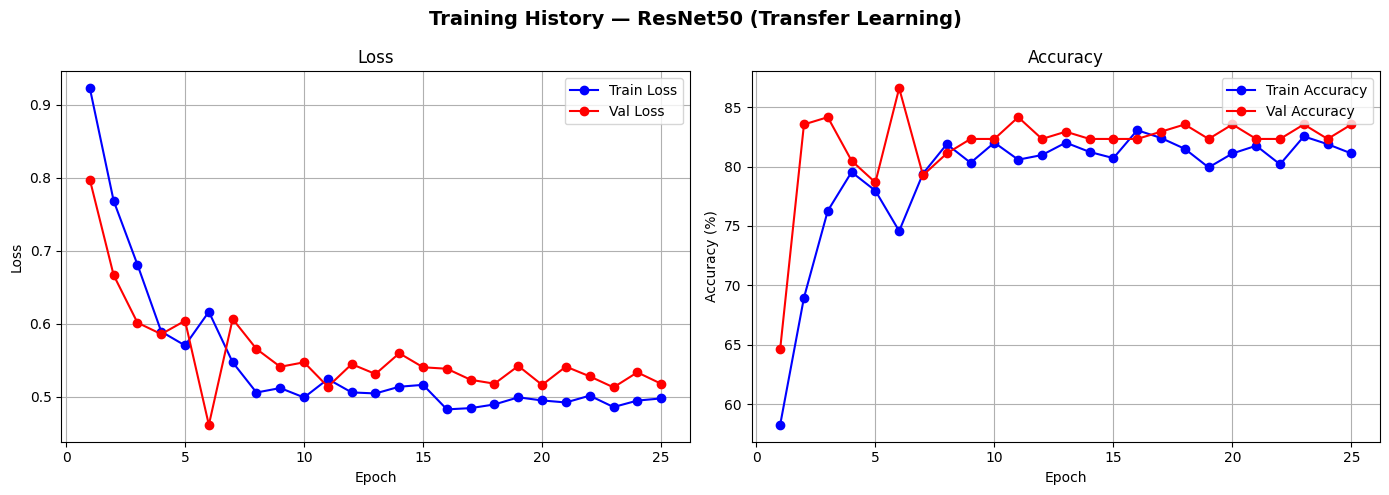

Saved → /content/checkpoints/ResNet50_(Transfer_Learning)_history.png


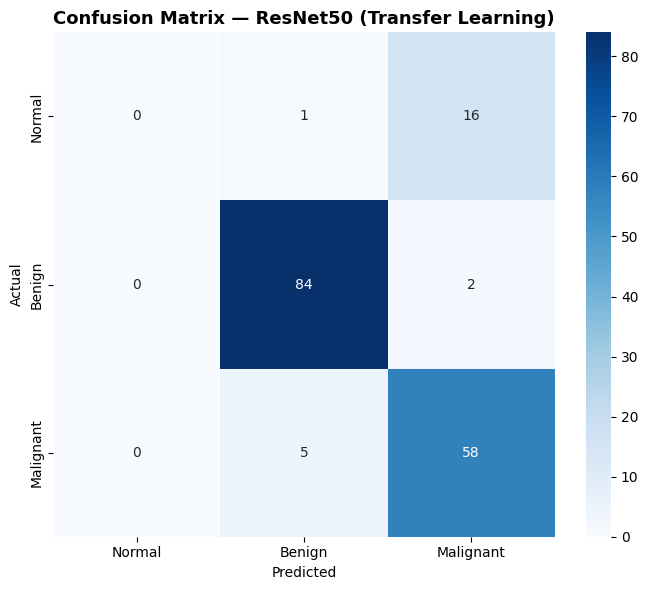

Saved → /content/checkpoints/ResNet50_(Transfer_Learning)_cm.png

[MODEL] DenseNet121 (Transfer Learning)
        Trainable params: 526,339 / 7,480,195

  Training : DenseNet121 (Transfer Learning)
  Epochs   : 25  |  Batch Size: 32
  LR       : 0.0001  |  Device: cpu


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch [01/25]  Train Loss: 0.9363 | Train Acc: 55.93%  Val Loss: 0.8506 | Val Acc: 70.12%  (229.5s)
  ✔  Saved best checkpoint → /content/checkpoints/DenseNet121_(Transfer_Learning)_best.pth


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/24 [00:00<?, ?it/s]

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch [25/25]  Train Loss: 0.5522 | Train Acc: 78.88%  Val Loss: 0.5220 | Val Acc: 84.15%  (229.6s)

✅ Best Val Accuracy for DenseNet121 (Transfer Learning): 84.15%


  Validating:   0%|          | 0/6 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
  EVALUATION RESULTS : DenseNet121 (Transfer Learning)
───────────────────────────────────────────────────────
  Accuracy  : 84.34%
  F1-Score  : 0.7977
  Precision : 0.7568
  Recall    : 0.8434

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        17
      Benign       0.86      0.97      0.91        86
   Malignant       0.83      0.90      0.86        63

    accuracy                           0.84       166
   macro avg       0.56      0.62      0.59       166
weighted avg       0.76      0.84      0.80       166



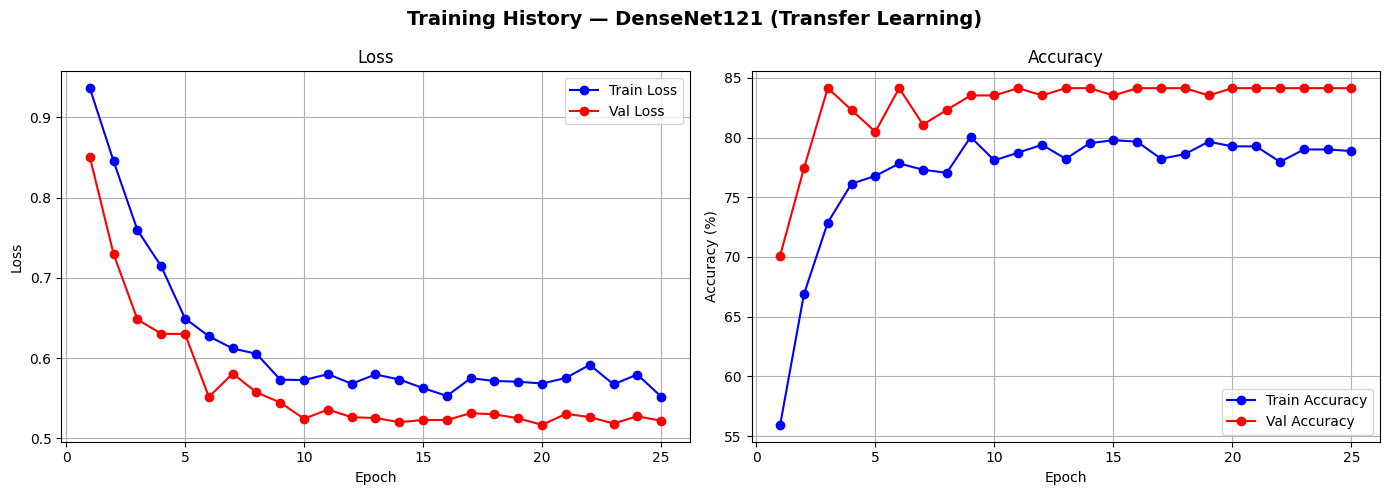

Saved → /content/checkpoints/DenseNet121_(Transfer_Learning)_history.png


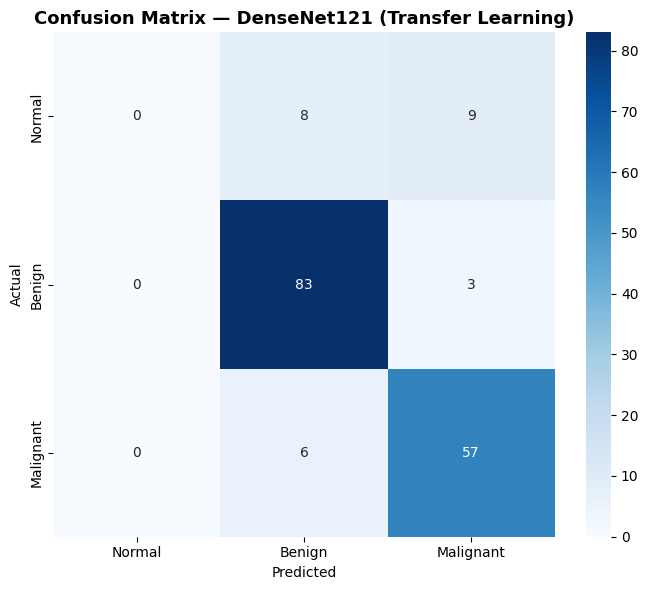

Saved → /content/checkpoints/DenseNet121_(Transfer_Learning)_cm.png

[MODEL] VGGNet (Transfer Learning)
        Trainable params: 106,962,947 / 121,677,635

  Training : VGGNet (Transfer Learning)
  Epochs   : 25  |  Batch Size: 32
  LR       : 0.0001  |  Device: cpu


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch [01/25]  Train Loss: 0.6358 | Train Acc: 75.10%  Val Loss: 0.6121 | Val Acc: 70.12%  (597.4s)
  ✔  Saved best checkpoint → /content/checkpoints/VGGNet_(Transfer_Learning)_best.pth


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

...

  Training:   0%|          | 0/24 [00:00<?, ?it/s]

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch [07/25]  Train Loss: 0.2811 | Train Acc: 87.74%  Val Loss: 0.4295 | Val Acc: 83.54%  (594.6s)


  Training:   0%|          | 0/24 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Step 1: Load Dataset ─────────────────────────────────────────────────────
# Auto-detected path is used from CONFIG["data_dir"]
# If DATA_DIR is None above, set it manually:
# CONFIG["data_dir"] = "/your/correct/path"

train_loader, val_loader, test_loader = prepare_dataloaders(CONFIG["data_dir"])

# ── Step 2: Visualise sample images from each class ──────────────────────────
from torchvision.utils import make_grid

def show_samples(loader, n=6):
    images, labels = next(iter(loader))
    fig, axes = plt.subplots(1, min(n, len(images)), figsize=(15, 3))
    for i, ax in enumerate(axes):
        img = images[i].permute(1, 2, 0).numpy()
        # Denormalize
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=10)
        ax.axis("off")
    plt.suptitle("Sample CT Scan Images", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_samples(train_loader)

# ── Step 3: Model Registry ────────────────────────────────────────────────────
model_registry = {
    "ResNet50 (Transfer Learning)"   : build_resnet50(CONFIG["num_classes"]),
    "DenseNet121 (Transfer Learning)": build_densenet121(CONFIG["num_classes"]),
    "VGGNet (Transfer Learning)"     : build_vgg16(CONFIG["num_classes"]),
}

device      = CONFIG["device"]
all_results = []

# ── Step 4: Train → Evaluate each model ──────────────────────────────────────
for model_name, model in model_registry.items():
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"\n[MODEL] {model_name}")
    print(f"        Trainable params: {trainable:,} / {total:,}")

    trained_model, history, ckpt_path = train_model(
        model, model_name, train_loader, val_loader, device
    )
    trained_model.load_state_dict(torch.load(ckpt_path, map_location=device))

    result = evaluate_model(trained_model, test_loader, device, model_name)
    all_results.append(result)

    plot_training_history(history, model_name)
    plot_confusion_matrix(result["preds"], result["labels"], model_name)


## Step 12: Final Results Summary & Model Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# SAVE ALL TRAINED MODELS AS PICKLE FILES
# ═══════════════════════════════════════════════════════════════════════

import os
import torch
import pickle
from google.colab import files

PICKLE_DIR = CONFIG["save_dir"]

os.makedirs(PICKLE_DIR, exist_ok=True)

# ── Model Builders ────────────────────────────────────────────
MODEL_BUILDERS = {
    "ResNet50 (Transfer Learning)"   : build_resnet50,
    "DenseNet121 (Transfer Learning)": build_densenet121,
    "VGGNet (Transfer Learning)"     : build_vgg16,
}

# ── Pickle Names ──────────────────────────────────────────────
PICKLE_NAMES = {
    "ResNet50 (Transfer Learning)"   : "ResNet50_model.pkl",
    "DenseNet121 (Transfer Learning)": "DenseNet121_model.pkl",
    "VGGNet (Transfer Learning)"     : "VGGNet_model.pkl",
}

print("💾 Creating Pickle Files...\n")

# ═══════════════════════════════════════════════════════════════
# PROCESS EACH MODEL
# ═══════════════════════════════════════════════════════════════

for model_name, build_fn in MODEL_BUILDERS.items():

    print(f"\n🔹 Processing: {model_name}")

    # ── Checkpoint Path ───────────────────────────────────────
    ckpt_path = os.path.join(
        PICKLE_DIR,
        f"{model_name.replace(' ','_')}_best.pth"
    )

    # ── Pickle Path ───────────────────────────────────────────
    pkl_path = os.path.join(
        PICKLE_DIR,
        PICKLE_NAMES[model_name]
    )

    # ── Build Model ───────────────────────────────────────────
    model = build_fn(CONFIG["num_classes"])

    # ── Load Checkpoint ───────────────────────────────────────
    checkpoint = torch.load(
        ckpt_path,
        map_location=CONFIG["device"]
    )

    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        print("   ✅ Full checkpoint loaded")

    except:
        model.load_state_dict(checkpoint)
        print("   ✅ Weights loaded")

    model.eval()

    # ── Save Pickle File ──────────────────────────────────────
    with open(pkl_path, "wb") as f:
        pickle.dump(model, f)

    size_mb = os.path.getsize(pkl_path) / (1024 * 1024)

    print(f"   ✅ Saved: {PICKLE_NAMES[model_name]}")
    print(f"   📦 Size : {size_mb:.1f} MB")

# ═══════════════════════════════════════════════════════════════
# DOWNLOAD FILES
# ═══════════════════════════════════════════════════════════════

print("\n⬇ Downloading Pickle Files...\n")

files.download('/content/checkpoints/ResNet50_model.pkl')
files.download('/content/checkpoints/DenseNet121_model.pkl')
files.download('/content/checkpoints/VGGNet_model.pkl')

💾 Creating Pickle Files...


🔹 Processing: ResNet50 (Transfer Learning)
   ✅ Weights loaded
   ✅ Saved: ResNet50_model.pkl
   📦 Size : 94.0 MB

🔹 Processing: DenseNet121 (Transfer Learning)
   ✅ Weights loaded
   ✅ Saved: DenseNet121_model.pkl
   📦 Size : 29.1 MB

🔹 Processing: VGGNet (Transfer Learning)
   ✅ Weights loaded
   ✅ Saved: VGGNet_model.pkl
   📦 Size : 464.2 MB

⬇ Downloading Pickle Files...



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ═══════════════════════════════════════════════════════════════
# ADD VGG16 RESULTS INTO all_results
# ═══════════════════════════════════════════════════════════════

import torch

# ── Build Model ───────────────────────────────────────────────
vgg_model = build_vgg16(CONFIG["num_classes"]).to(CONFIG["device"])

# ── Load Saved Checkpoint ─────────────────────────────────────
checkpoint_path = "/content/checkpoints/VGGNet_(Transfer_Learning)_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location=CONFIG["device"]
)

try:
    vgg_model.load_state_dict(checkpoint['model_state_dict'])

except:
    vgg_model.load_state_dict(checkpoint)

vgg_model.eval()

# ── Evaluate Model ────────────────────────────────────────────
vgg_result = evaluate_model(
    vgg_model,
    test_loader,
    CONFIG["device"],
    "VGGNet (Transfer Learning)"
)

# ── Add to all_results ────────────────────────────────────────
all_results.append(vgg_result)

print("✅ VGG16 added successfully to all_results")

  Validating:   0%|          | 0/6 [00:00<?, ?it/s]


───────────────────────────────────────────────────────
  EVALUATION RESULTS : VGGNet (Transfer Learning)
───────────────────────────────────────────────────────
  Accuracy  : 89.76%
  F1-Score  : 0.8707
  Precision : 0.8739
  Recall    : 0.8976

              precision    recall  f1-score   support

      Normal       0.50      0.12      0.19        17
      Benign       1.00      1.00      1.00        86
   Malignant       0.80      0.97      0.88        63

    accuracy                           0.90       166
   macro avg       0.77      0.70      0.69       166
weighted avg       0.87      0.90      0.87       166

✅ VGG16 added successfully to all_results


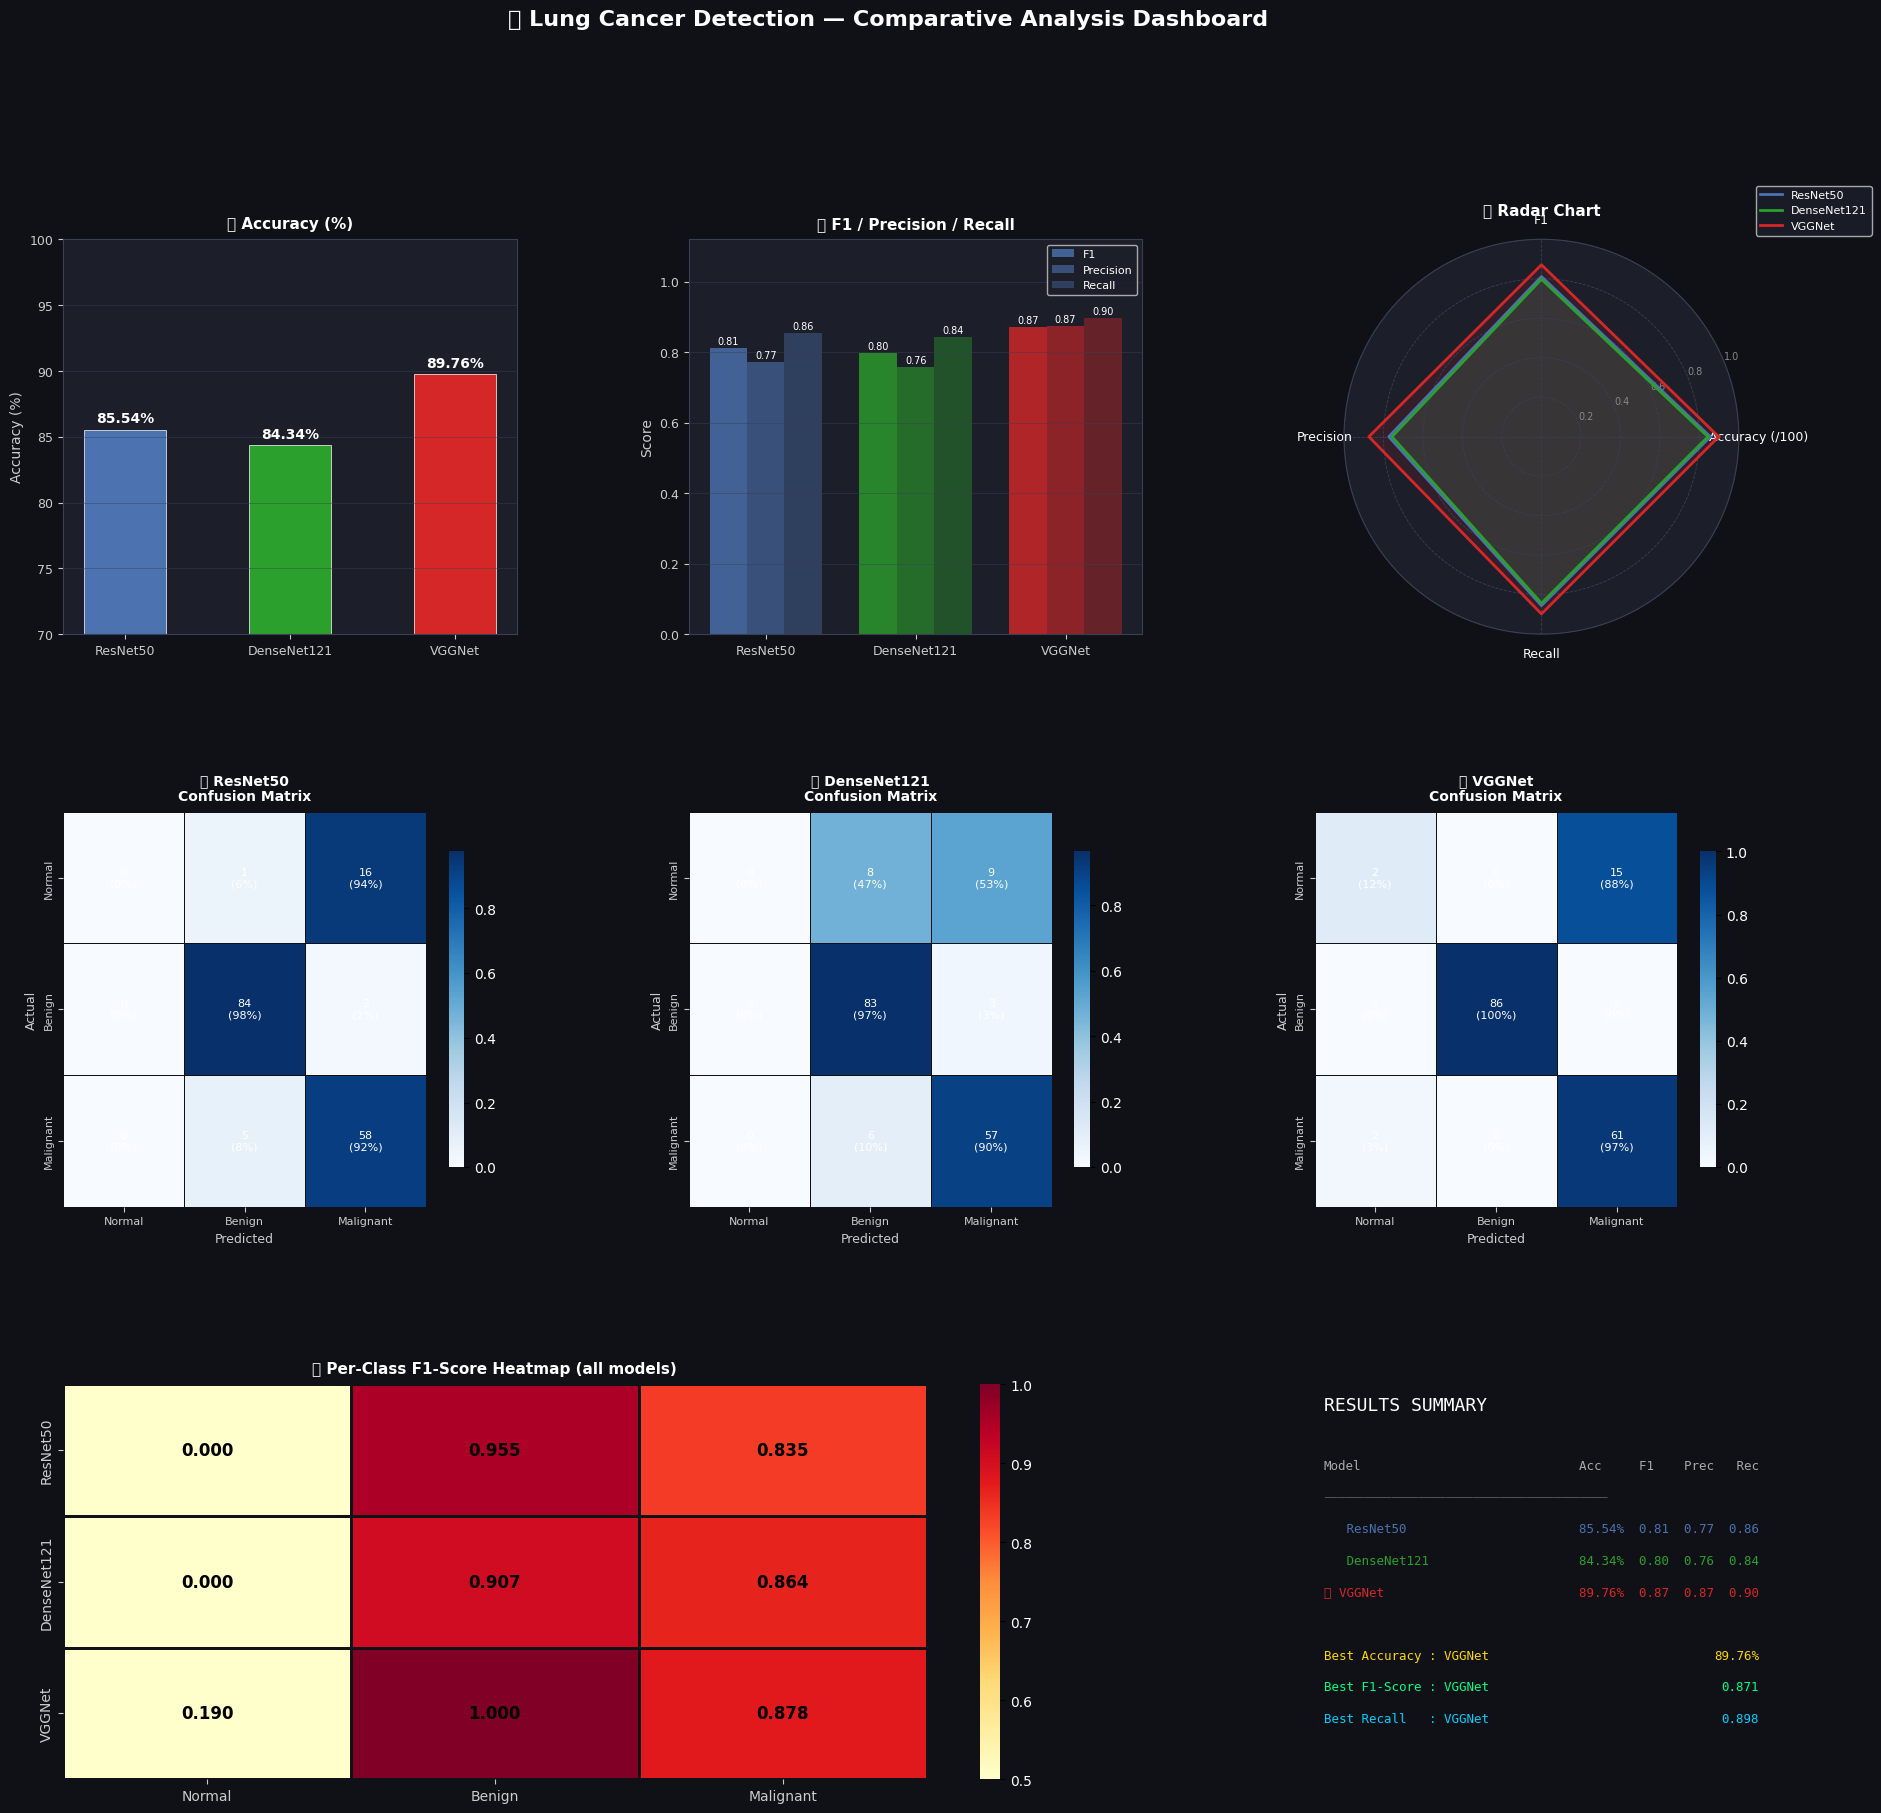

✅ Dashboard saved → /content/checkpoints/comparative_analysis_dashboard.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 12B — COMPARATIVE ANALYSIS DASHBOARD
#  Side-by-side comparison of ResNet50 | DenseNet121 | VGG16
#  Panels: Metric bars | Radar chart | Per-class heatmap | Confusion matrices
# ═══════════════════════════════════════════════════════════════════════════

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# ── Colour palette ────────────────────────────────────────────────────────────
COLORS = {
    "ResNet50 (Transfer Learning)"   : "#4C72B0",
    "DenseNet121 (Transfer Learning)": "#2CA02C",
    "VGGNet (Transfer Learning)"     : "#D62728"
}

MODEL_SHORT = {
    "ResNet50 (Transfer Learning)"   : "ResNet50",
    "DenseNet121 (Transfer Learning)": "DenseNet121",
    "VGGNet (Transfer Learning)"     : "VGGNet"
}

def draw_dashboard(all_results):
    fig = plt.figure(figsize=(22, 20))
    fig.patch.set_facecolor('#0F1117')
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

    names = [MODEL_SHORT[r["model"]] for r in all_results]
    colors = [COLORS[r["model"]] for r in all_results]
    acc    = [r["accuracy"] for r in all_results]
    f1     = [r["f1"] for r in all_results]
    prec   = [r["precision"] for r in all_results]
    rec    = [r["recall"] for r in all_results]

    # ── Helper: dark axis ────────────────────────────────────────────────────
    def dark_ax(ax, title=""):
        ax.set_facecolor('#1C1F2A')
        for spine in ax.spines.values():
            spine.set_edgecolor('#3A3F55')
        ax.tick_params(colors='#CCCCCC', labelsize=9)
        ax.xaxis.label.set_color('#CCCCCC')
        ax.yaxis.label.set_color('#CCCCCC')
        if title:
            ax.set_title(title, color='white', fontsize=11, fontweight='bold', pad=8)
        ax.grid(axis='y', color='#3A3F55', alpha=0.5, linewidth=0.6)

    # ── Panel 1: Accuracy bar chart ─────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    bars = ax1.bar(names, acc, color=colors, width=0.5, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, acc):
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.2f}%',
            ha='center',
            va='bottom',
            color='white',
            fontsize=10,
            fontweight='bold'
        )
    ax1.set_ylim(70, 100)
    ax1.set_ylabel('Accuracy (%)')
    dark_ax(ax1, '📊 Accuracy (%)')

    # ── Panel 2: F1 / Precision / Recall grouped bars ───────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    x = np.arange(len(names))
    w = 0.25

    b1 = ax2.bar(x - w, f1,   w, label='F1',        color=[c + 'CC' for c in colors])
    b2 = ax2.bar(x,     prec, w, label='Precision', color=[c + '99' for c in colors])
    b3 = ax2.bar(x + w, rec,  w, label='Recall',    color=[c + '66' for c in colors])

    ax2.set_xticks(x)
    ax2.set_xticklabels(names)
    ax2.set_ylim(0, 1.12)
    ax2.set_ylabel('Score')
    ax2.legend(facecolor='#1C1F2A', labelcolor='white', fontsize=8)
    dark_ax(ax2, '📈 F1 / Precision / Recall')

    for bars_grp in [b1, b2, b3]:
        for bar in bars_grp:
            ax2.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.2f}',
                ha='center',
                va='bottom',
                color='white',
                fontsize=7
            )

    # ── Panel 3: Radar / Spider chart ───────────────────────────────────────
    ax3 = fig.add_subplot(gs[0, 2], polar=True)
    ax3.set_facecolor('#1C1F2A')

    cats = ['Accuracy (/100)', 'F1', 'Precision', 'Recall']
    N = len(cats)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(cats, color='white', size=9)
    ax3.set_ylim(0, 1)
    ax3.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax3.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color='#888', size=7)
    ax3.grid(color='#3A3F55', linestyle='--', linewidth=0.6)
    ax3.spines['polar'].set_color('#3A3F55')

    for r in all_results:
        vals = [r["accuracy"] / 100, r["f1"], r["precision"], r["recall"]]
        vals += vals[:1]
        ax3.plot(
            angles, vals,
            linewidth=2,
            color=COLORS[r["model"]],
            label=MODEL_SHORT[r["model"]]
        )
        ax3.fill(angles, vals, alpha=0.12, color=COLORS[r["model"]])

    ax3.legend(
        loc='upper right',
        bbox_to_anchor=(1.35, 1.15),
        facecolor='#1C1F2A',
        labelcolor='white',
        fontsize=8
    )
    ax3.set_title('🕸 Radar Chart', color='white', fontsize=11, fontweight='bold', pad=18)

    # ── Panel 4-6: Confusion matrix per model ────────────────────────────────
    for idx, r in enumerate(all_results):
        ax = fig.add_subplot(gs[1, idx])
        cm = confusion_matrix(r["labels"], r["preds"])

        # Row-normalise safely
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_norm = cm.astype(float) / row_sums

        annot = np.array([
            [f"{v}\n({p:.0%})" for v, p in zip(row_v, row_p)]
            for row_v, row_p in zip(cm, cm_norm)
        ])

        sns.heatmap(
            cm_norm,
            annot=annot,
            fmt='',
            cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES,
            ax=ax,
            linewidths=0.5,
            linecolor='#0F1117',
            annot_kws={"size": 8, "color": "white"},
            cbar_kws={"shrink": 0.8}
        )

        ax.set_facecolor('#1C1F2A')
        ax.tick_params(colors='#CCCCCC', labelsize=8)
        ax.set_xlabel('Predicted', color='#CCCCCC', fontsize=9)
        ax.set_ylabel('Actual', color='#CCCCCC', fontsize=9)
        ax.set_title(
            f'🔲 {MODEL_SHORT[r["model"]]}\nConfusion Matrix',
            color='white',
            fontsize=10,
            fontweight='bold',
            pad=8
        )
        ax.collections[0].colorbar.ax.tick_params(labelcolor='white')

    # ── Panel 7: Per-class F1 heatmap ────────────────────────────────────────
    ax7 = fig.add_subplot(gs[2, 0:2])

    per_class = []
    for r in all_results:
        report = classification_report(
            r["labels"],
            r["preds"],
            target_names=CLASS_NAMES,
            output_dict=True,
            zero_division=0
        )
        row = [report[c]["f1-score"] for c in CLASS_NAMES]
        per_class.append(row)

    hm_data = np.array(per_class)
    annot_d = [[f"{v:.3f}" for v in row] for row in hm_data]

    sns.heatmap(
        hm_data,
        annot=annot_d,
        fmt='',
        cmap='YlOrRd',
        xticklabels=CLASS_NAMES,
        yticklabels=[MODEL_SHORT[r["model"]] for r in all_results],
        ax=ax7,
        linewidths=1,
        linecolor='#0F1117',
        annot_kws={"size": 12, "color": "black", "weight": "bold"},
        vmin=0.5,
        vmax=1.0
    )

    ax7.set_facecolor('#1C1F2A')
    ax7.tick_params(colors='#CCCCCC', labelsize=10)
    ax7.set_title(
        '🎯 Per-Class F1-Score Heatmap (all models)',
        color='white',
        fontsize=11,
        fontweight='bold',
        pad=8
    )
    ax7.collections[0].colorbar.ax.tick_params(labelcolor='white')

    # ── Panel 8: Summary scoreboard ─────────────────────────────────────────
    ax8 = fig.add_subplot(gs[2, 2])
    ax8.set_facecolor('#1C1F2A')
    ax8.axis('off')

    best_r = max(all_results, key=lambda x: x["accuracy"])
    best_f1 = max(all_results, key=lambda x: x["f1"])
    best_rec = max(all_results, key=lambda x: x["recall"])

    lines = [
        ("RESULTS SUMMARY", "", "white", 13),
        ("", "", "white", 8),
        ("Model", "Acc     F1    Prec   Rec", "#AAAAAA", 9),
        ("─" * 42, "", "#555", 8),
    ]

    for r in all_results:
        mark = "🏆 " if r == best_r else "   "
        lines.append((
            f"{mark}{MODEL_SHORT[r['model']]}",
            f"{r['accuracy']:5.2f}%  {r['f1']:.2f}  {r['precision']:.2f}  {r['recall']:.2f}",
            COLORS[r['model']],
            9
        ))

    lines += [
        ("", "", "white", 8),
        (f"Best Accuracy : {MODEL_SHORT[best_r['model']]}", f"{best_r['accuracy']:.2f}%", "#FFD700", 9),
        (f"Best F1-Score : {MODEL_SHORT[best_f1['model']]}", f"{best_f1['f1']:.3f}", "#00FF88", 9),
        (f"Best Recall   : {MODEL_SHORT[best_rec['model']]}", f"{best_rec['recall']:.3f}", "#00CFFF", 9),
    ]

    y = 0.97
    for (left, right, color, fsize) in lines:
        ax8.text(
            0.02, y, left,
            transform=ax8.transAxes,
            color=color,
            fontsize=fsize,
            va='top',
            fontfamily='monospace'
        )
        ax8.text(
            0.98, y, right,
            transform=ax8.transAxes,
            color=color,
            fontsize=fsize,
            va='top',
            ha='right',
            fontfamily='monospace'
        )
        y -= 0.08

    fig.suptitle(
        '🫁 Lung Cancer Detection — Comparative Analysis Dashboard',
        color='white',
        fontsize=16,
        fontweight='bold',
        y=0.995
    )

    save_path = os.path.join(CONFIG["save_dir"], "comparative_analysis_dashboard.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
    plt.show()
    print(f"✅ Dashboard saved → {save_path}")

draw_dashboard(all_results)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 13 — CANCER PREDICTION SYSTEM
#  • Loads all 3 pickle models
#  • Accepts any CT scan image (upload or path)
#  • Runs inference through all 3 models
#  • Displays unified verdict: CANCER DETECTED / NO CANCER + confidence
#  • Shows individual model predictions side-by-side
# ═══════════════════════════════════════════════════════════════════════════

import pickle, os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import numpy as np
import torch
from torchvision import transforms
from google.colab import files as colab_files   # Colab file uploader

# ── Inference transform (no augmentation) ────────────────────────────────────
INFER_TF = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

CLASS_NAMES  = ["Normal", "Benign", "Malignant"]
PICKLE_DIR   = CONFIG["save_dir"]
DEVICE       = CONFIG["device"]

PICKLE_FILES = {
    "ResNet50"   : "ResNet50_model.pkl",
    "DenseNet121": "DenseNet121_model.pkl",
    "VGGNet"     : "VGGNet_model.pkl",
}
MODEL_COLORS = {
    "ResNet50"   : "#4C72B0",
    "DenseNet121": "#2CA02C",
    "VGGNet"     : "#D62728",
}

# ── Load all 3 pickle models ─────────────────────────────────────────────────
def load_all_pickles():
    loaded = {}
    print("📦 Loading pickle models...")
    for name, fname in PICKLE_FILES.items():
        path = os.path.join(PICKLE_DIR, fname)
        if not os.path.exists(path):
            print(f"  ⚠️  {fname} not found — run training cells first")
            continue
        with open(path, "rb") as f:
            model = pickle.load(f)
        model.eval()
        model.to(DEVICE)
        loaded[name] = model
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"  ✅ {name:<12} loaded from {fname}  ({size_mb:.1f} MB)")
    return loaded

# ── Predict with a single model ──────────────────────────────────────────────
def predict_one(model, image_tensor):
    """Returns (class_name, confidence_pct, probs_dict)"""
    with torch.no_grad():
        logits = model(image_tensor.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)[0].cpu().numpy()
    idx   = int(np.argmax(probs))
    return CLASS_NAMES[idx], float(probs[idx]) * 100, {
        CLASS_NAMES[i]: round(float(probs[i]) * 100, 2) for i in range(3)
    }

# ── Ensemble verdict ─────────────────────────────────────────────────────────
def ensemble_verdict(predictions):
    """
    Majority vote across 3 models.
    'Cancer' = Benign OR Malignant
    'No Cancer' = Normal
    Returns: verdict string, confidence, breakdown dict
    """
    votes       = [p["class"] for p in predictions.values()]
    cancer_vote = sum(1 for v in votes if v != "Normal")
    no_cancer   = sum(1 for v in votes if v == "Normal")

    # Average malignant probability across all models
    avg_malignant = np.mean([p["probs"]["Malignant"] for p in predictions.values()])
    avg_normal    = np.mean([p["probs"]["Normal"]    for p in predictions.values()])
    avg_benign    = np.mean([p["probs"]["Benign"]    for p in predictions.values()])

    if cancer_vote >= 2:
        if avg_malignant > avg_benign:
            verdict    = "⚠️  MALIGNANT CANCER DETECTED"
            verdict_short = "MALIGNANT"
            color      = "#FF4444"
        else:
            verdict    = "⚠️  BENIGN TUMOUR DETECTED"
            verdict_short = "BENIGN"
            color      = "#FF8C00"
        confidence = max(avg_malignant, avg_benign)
    else:
        verdict    = "✅  NO CANCER DETECTED"
        verdict_short = "NORMAL"
        color      = "#00CC66"
        confidence = avg_normal

    return verdict, verdict_short, confidence, color

# ── Master prediction & display function ─────────────────────────────────────
def predict_and_display(image_path, loaded_models):
    """
    Full prediction pipeline:
    1. Preprocess image
    2. Run through all 3 models
    3. Show unified verdict + per-model breakdown
    """
    # ── Load & preprocess ────────────────────────────────────────────────────
    raw_img    = Image.open(image_path).convert("RGB")
    img_tensor = INFER_TF(raw_img).unsqueeze(0)   # [1,3,224,224]

    # ── Per-model predictions ────────────────────────────────────────────────
    predictions = {}
    for name, model in loaded_models.items():
        cls, conf, probs = predict_one(model, img_tensor)
        predictions[name] = {"class": cls, "confidence": conf, "probs": probs}

    # ── Ensemble verdict ─────────────────────────────────────────────────────
    verdict, verdict_short, ens_conf, verdict_color = ensemble_verdict(predictions)

    # ══════════════════════════════════════════════════════════════════════════
    #  VISUALISATION
    # ══════════════════════════════════════════════════════════════════════════
    fig = plt.figure(figsize=(20, 14), facecolor='#0F1117')
    gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.38,
                            height_ratios=[1.6, 1.2, 1.2])

    # ── A: Input image (large, left) ─────────────────────────────────────────
    ax_img = fig.add_subplot(gs[0:2, 0])
    ax_img.imshow(raw_img, cmap='gray')
    ax_img.set_title('Input CT Scan', color='white', fontsize=12, fontweight='bold', pad=8)
    ax_img.axis('off')
    # Coloured border = verdict
    for spine in ax_img.spines.values():
        spine.set_edgecolor(verdict_color)
        spine.set_linewidth(4)

    # ── B: Verdict banner ────────────────────────────────────────────────────
    ax_verd = fig.add_subplot(gs[0, 1:4])
    ax_verd.set_facecolor(verdict_color + '22')
    ax_verd.axis('off')
    ax_verd.text(0.5, 0.62, verdict,
                 transform=ax_verd.transAxes, ha='center', va='center',
                 fontsize=22, fontweight='bold', color=verdict_color)
    ax_verd.text(0.5, 0.28,
                 f"Ensemble Confidence: {ens_conf:.1f}%   |   "
                 f"Models agreed: {sum(1 for p in predictions.values() if p['class'] == list(predictions.values())[0]['class'])}/3",
                 transform=ax_verd.transAxes, ha='center', va='center',
                 fontsize=12, color='#CCCCCC')
    for spine in ax_verd.spines.values():
        spine.set_edgecolor(verdict_color)
        spine.set_linewidth(2)

    # ── C: Per-model prediction bars ─────────────────────────────────────────
    for col_idx, (mname, pred) in enumerate(predictions.items()):
        ax = fig.add_subplot(gs[1, col_idx+1])
        ax.set_facecolor('#1C1F2A')
        bar_colors = []
        for c in CLASS_NAMES:
            if c == pred["class"]:
                bar_colors.append(MODEL_COLORS[mname])
            else:
                bar_colors.append('#3A3F55')
        bars = ax.barh(CLASS_NAMES,
                       [pred["probs"][c] for c in CLASS_NAMES],
                       color=bar_colors, edgecolor='#0F1117', linewidth=0.5)
        ax.set_xlim(0, 100)
        ax.set_xlabel('Probability (%)', color='#CCCCCC', fontsize=8)
        for spine in ax.spines.values():
            spine.set_edgecolor(MODEL_COLORS[mname])
            spine.set_linewidth(1.5)
        ax.tick_params(colors='#CCCCCC', labelsize=9)
        ax.xaxis.label.set_color('#CCCCCC')
        ax.set_title(f'{mname}\n→ {pred["class"]} ({pred["confidence"]:.1f}%)',
                     color='white', fontsize=10, fontweight='bold', pad=6)
        ax.grid(axis='x', color='#3A3F55', alpha=0.4, linewidth=0.5)
        for bar, cls in zip(bars, CLASS_NAMES):
            val = pred["probs"][cls]
            ax.text(min(val + 1, 95), bar.get_y() + bar.get_height()/2,
                    f'{val:.1f}%', va='center', color='white', fontsize=8.5,
                    fontweight='bold' if cls == pred["class"] else 'normal')

    # ── D: Average probability across all models (ensemble breakdown) ─────────
    ax_ens = fig.add_subplot(gs[2, 1:3])
    ax_ens.set_facecolor('#1C1F2A')
    avg_probs = {c: np.mean([predictions[m]["probs"][c] for m in predictions]) for c in CLASS_NAMES}
    ens_colors = []
    for c in CLASS_NAMES:
        if c == "Normal":
            ens_colors.append("#00CC66")
        elif c == "Benign":
            ens_colors.append("#FF8C00")
        else:
            ens_colors.append("#FF4444")
    bars = ax_ens.bar(CLASS_NAMES, list(avg_probs.values()),
                      color=ens_colors, edgecolor='#0F1117', linewidth=0.5, width=0.5)
    for bar, (cls, val) in zip(bars, avg_probs.items()):
        ax_ens.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                    f'{val:.1f}%', ha='center', va='bottom', color='white',
                    fontsize=11, fontweight='bold')
    ax_ens.set_ylim(0, 110)
    ax_ens.set_ylabel('Avg Probability (%)', color='#CCCCCC', fontsize=9)
    ax_ens.tick_params(colors='#CCCCCC', labelsize=10)
    ax_ens.set_facecolor('#1C1F2A')
    for spine in ax_ens.spines.values():
        spine.set_edgecolor('#3A3F55')
    ax_ens.grid(axis='y', color='#3A3F55', alpha=0.4)
    ax_ens.set_title('🔀 Ensemble — Average Probability (3 models)',
                     color='white', fontsize=11, fontweight='bold', pad=8)

    # ── E: Voting summary table ───────────────────────────────────────────────
    ax_vote = fig.add_subplot(gs[2, 3])
    ax_vote.set_facecolor('#1C1F2A')
    ax_vote.axis('off')
    for spine in ax_vote.spines.values():
        spine.set_edgecolor('#3A3F55')

    lines = [
        ("MODEL VOTES", "#FFFFFF", 10),
        ("──────────────────", "#444", 8),
    ]
    for mname, pred in predictions.items():
        cls   = pred["class"]
        cvote = "#FF4444" if cls == "Malignant" else "#FF8C00" if cls == "Benign" else "#00CC66"
        lines.append((f"{mname:<12}:  {cls}", cvote, 9))

    lines += [
        ("──────────────────", "#444", 8),
        (f"VERDICT: {verdict_short}", verdict_color, 11),
        (f"Confidence: {ens_conf:.1f}%", "#FFFFFF", 9),
    ]
    y = 0.95
    for (text, color, fsize) in lines:
        ax_vote.text(0.08, y, text, transform=ax_vote.transAxes,
                     color=color, fontsize=fsize, va='top', fontfamily='monospace',
                     fontweight='bold' if 'VERDICT' in text else 'normal')
        y -= 0.10

    # ── E: input path watermark ──────────────────────────────────────────────
    ax_vote2 = fig.add_subplot(gs[2, 0])
    ax_vote2.set_facecolor('#1C1F2A')
    ax_vote2.axis('off')
    ax_vote2.text(0.5, 0.55, '🫁', transform=ax_vote2.transAxes,
                  ha='center', va='center', fontsize=48)
    ax_vote2.text(0.5, 0.18, os.path.basename(image_path),
                  transform=ax_vote2.transAxes, ha='center', color='#888', fontsize=8)
    for spine in ax_vote2.spines.values():
        spine.set_edgecolor('#3A3F55')

    fig.suptitle('🫁  Lung Cancer Detection System — Full Model Prediction Report',
                 color='white', fontsize=15, fontweight='bold', y=1.01)

    out_path = os.path.join(PICKLE_DIR, "prediction_result.png")
    plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#0F1117')
    plt.show()
    print(f"\n✅ Prediction report saved → {out_path}")

    # ── Console summary ───────────────────────────────────────────────────────
    print(f"\n{'═'*55}")
    print(f"  FINAL VERDICT : {verdict}")
    print(f"  Confidence    : {ens_conf:.1f}%")
    print(f"{'─'*55}")
    for mname, pred in predictions.items():
        print(f"  {mname:<14}: {pred['class']:<12} ({pred['confidence']:.1f}%)")
    print(f"{'═'*55}")

    return predictions, verdict, ens_conf


# ─────────────────────────────────────────────────────────────────────────────
#  MAIN: Load models → Upload image → Predict
# ─────────────────────────────────────────────────────────────────────────────

# Step 1: Load all 3 pickle models
loaded_models = load_all_pickles()

# Step 2: Upload a CT scan image
print("\n📤 Please upload a CT scan image (.jpg / .png / .bmp)...")
uploaded = colab_files.upload()

# Step 3: Run prediction
if uploaded:
    image_path = list(uploaded.keys())[0]
    print(f"\n🔍 Running prediction on: {image_path}")
    predictions, verdict, confidence = predict_and_display(image_path, loaded_models)
else:
    print("⚠️  No image uploaded. To test manually:")
    print("   predict_and_display('your_scan.jpg', loaded_models)")


📦 Loading pickle models...
  ✅ ResNet50     loaded from ResNet50_model.pkl  (94.0 MB)
  ✅ DenseNet121  loaded from DenseNet121_model.pkl  (29.1 MB)
  ✅ VGGNet       loaded from VGGNet_model.pkl  (464.2 MB)

📤 Please upload a CT scan image (.jpg / .png / .bmp)...
